# Resource estimation for simulating an extended Kitaev honeycomb model

In this notebook we demonstrate how to estimate the resources for quantum dynamics, specifically the simulation of an extended Kitaev (Kitaev–Heisenberg–Γ–Γ′) Hamiltonian on an open
$N \times N$ honeycomb lattice of complete hexagonal plaquettes, using a fourth-order Trotter-Suzuki product formula.

The Hamiltonian terms are organized into lattice-aware commuting groups and parallel layers prior to Trotterization, which exploits the lattice structure and bond flavors of the model to make the circuit cheaper to run fault-tolerantly.

We use:
- **qdk-chemistry** for all domain-specific functionality (lattice geometry, model Hamiltonians, `EulerEvolutionCircuitBuilder` time evolution, circuit construction)
- **qdk.qre** for quantum resource estimation

## Background: extended Kitaev model

In the Kitaev honeycomb model each bond carries one of three flavors $\gamma \in \{x, y, z\}$ and couples only the $\gamma$ spin components of its two sites. Candidate spin-liquid materials such as α-RuCl₃ add Heisenberg exchange, off-diagonal $\Gamma$ and $\Gamma'$ interactions, and further-neighbor couplings, and an in-plane magnetic field suppresses their magnetic order.
Writing $\langle i, j\rangle_n$ for the $n$-th-neighbor bonds, $\gamma$ for the flavor of bond $(i, j)$, and $(\alpha, \beta)$ for the other two spin components, the Hamiltonian we consider is:

$$
\begin{aligned}
H &= \sum_{n=1}^{3} \sum_{\langle i, j\rangle_n} \Big[ J_n\,\mathbf{S}_i\cdot\mathbf{S}_j + K_n\,S_i^\gamma S_j^\gamma \Big] \\
&\quad + \sum_{\langle i, j\rangle_1} \Big[ \Gamma\,\big(S_i^\alpha S_j^\beta + S_i^\beta S_j^\alpha\big) + \Gamma'\,\big(S_i^\alpha S_j^\gamma + S_i^\gamma S_j^\alpha + S_i^\beta S_j^\gamma + S_i^\gamma S_j^\beta\big) \Big] \\
&\quad + \mu_B \sum_i \big(g_a H_a S_i^a + g_b H_b S_i^b + g_c H_c S_i^c\big)
\end{aligned}
$$
where the Heisenberg couplings $J_n$ and Kitaev couplings $K_n$ take separate values on first-, second-, and third-neighbor bonds, while $\Gamma$ and $\Gamma'$ act only on first-neighbor bonds. Further-neighbor bonds carry flavors too: a third-neighbor bond takes the flavor of the parallel first-neighbor bond, and a second-neighbor bond that of the first-neighbor bond perpendicular to it. The magnetic field $\mathbf{H}$ and $g$-factors are given in the crystallographic $(a, b, c)$ frame.

## Creating the Kitaev model

We use `qdk_chemistry` to define the lattice geometry and build the
Hamiltonian. `LatticeGeometry.honeycomb_plaquettes` creates an open honeycomb
lattice of complete hexagonal plaquettes, and `LatticeGraph.from_geometry`
labels its first-, second-, and third-neighbor bonds by distance shell and,
through `kitaev_honeycomb_bond_flavors`, by bond flavor.
`create_kitaev_hamiltonian` produces the corresponding `QubitOperator`, with
couplings in meV and a 10 T field along the crystallographic $b$ axis. The
exchange couplings are the first-principles values for α-RuCl₃ of Eichstaedt
et al. [1], taken from their model without non-local spin-orbit coupling.

The Hamiltonian is static, so we wrap it in a `DrivenQubitHamiltonian` without
a drive, matching the input interface required by `EulerIntegrator`. Without a
drive, the propagator returns the static Hamiltonian unchanged, including its
term partition.

By default `create_kitaev_hamiltonian` stores a lattice-aware
group-and-layer structure on `QubitOperator.term_partition`
(strategy `geometry_coloring`). Terms in a group commute, and terms in the
same layer act on disjoint qubits, so the corresponding Pauli exponentials
can be applied in parallel.

**References**

1. C. Eichstaedt, Y. Zhang, P. Laurell, S. Okamoto, A. G. Eguiluz, and T. Berlijn, *Deriving models for the Kitaev spin-liquid candidate material α-RuCl₃ from first principles*, Phys. Rev. B **100**, 075110 (2019). [doi:10.1103/PhysRevB.100.075110](https://doi.org/10.1103/PhysRevB.100.075110)

In [1]:
import numpy as np

from qdk_chemistry.algorithms import create
from qdk_chemistry.constants import BOHR_MAGNETON, ELEMENTARY_CHARGE
from qdk_chemistry.data import (
    AlgorithmRef, DrivenQubitHamiltonian, LatticeGeometry, LatticeGraph,
)
from qdk_chemistry.utils.model_hamiltonians import create_kitaev_hamiltonian, kitaev_honeycomb_bond_flavors

# Reduce logging output for demo
from qdk_chemistry.utils import Logger
Logger.set_global_level(Logger.LogLevel.off)

# Lattice dimensions, in complete hexagonal plaquettes
nx, ny = 10, 10
geometry = LatticeGeometry.honeycomb_plaquettes(nx, ny)
lattice = LatticeGraph.from_geometry(geometry, shells=[1, 2, 3], bond_flavors=kitaev_honeycomb_bond_flavors())

# Rows express the crystallographic a, b, c axes in the spin (x, y, z) frame
crystallographic_transform = np.array([
    [1 / np.sqrt(6), 1 / np.sqrt(6), -2 / np.sqrt(6)],
    [-1 / np.sqrt(2), 1 / np.sqrt(2), 0.0],
    [1 / np.sqrt(3), 1 / np.sqrt(3), 1 / np.sqrt(3)],
])
kitaev_couplings = {1: -13.3, 2: -0.67, 3: 0.1}  # meV, by neighbor shell

h0 = create_kitaev_hamiltonian(
    lattice,
    kx=kitaev_couplings,
    ky=kitaev_couplings,
    kz=kitaev_couplings,
    j={1: -1.3, 3: 1.0},  # meV; J2 = 0
    gamma=9.4,  # meV
    gamma_prime=-2.3,  # meV
    magnetic_field_abc=(0.0, 10.0, 0.0),  # tesla; H_b = 10 T
    g_factors_abc=(2.3, 2.3, 1.3),
    bohr_magneton=BOHR_MAGNETON / ELEMENTARY_CHARGE * 1e3,  # meV/T
    crystallographic_transform=crystallographic_transform,
    include_term_groups=True,
)

# Static Hamiltonian H(t) = H0: no drive term
td_hamiltonian = DrivenQubitHamiltonian(h0)

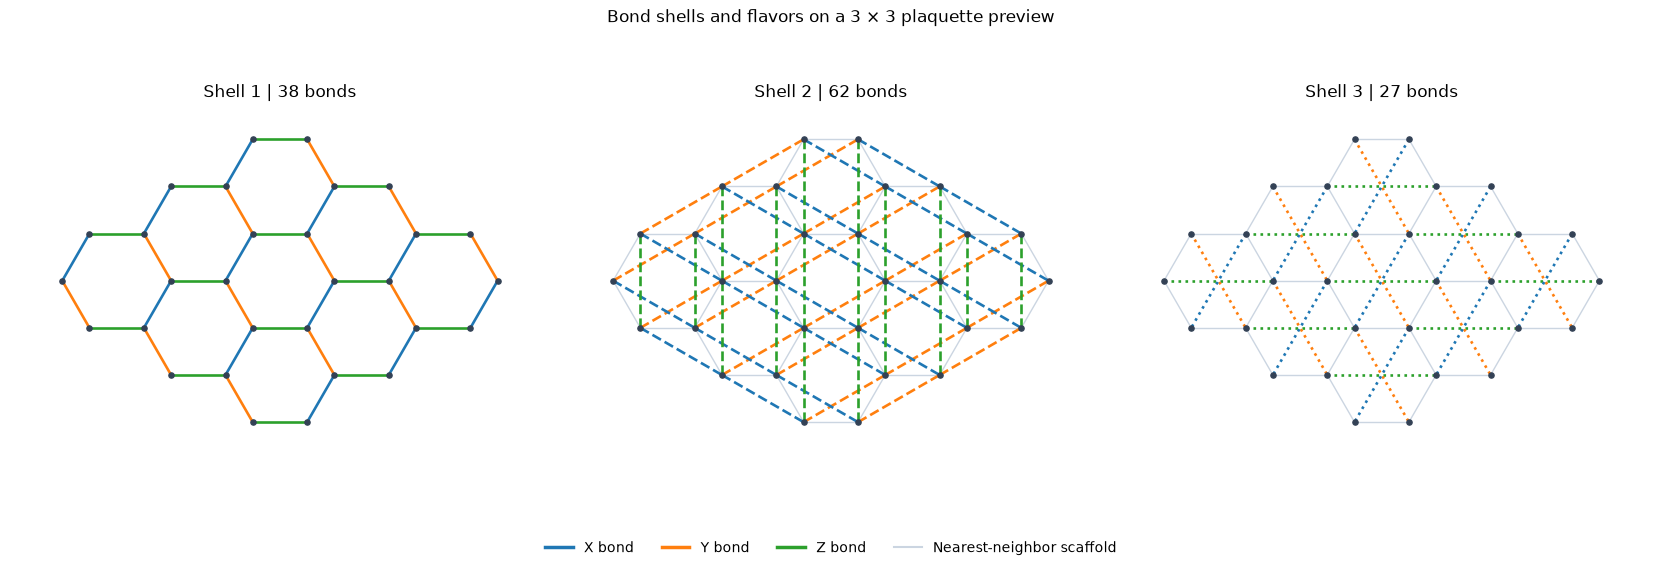

In [2]:
import matplotlib.pyplot as plt

from qdk_chemistry.utils.model_hamiltonians import KitaevBondFlavor
from utils.lattice_plotting import plot_lattice_graph

# A 3×3 preview built the same way; the full 10×10 lattice is too dense to read.
preview_geometry = LatticeGeometry.honeycomb_plaquettes(3, 3)
preview_lattice = LatticeGraph.from_geometry(
    preview_geometry, shells=[1, 2, 3], bond_flavors=kitaev_honeycomb_bond_flavors()
)
fig, axes = plot_lattice_graph(
    preview_lattice,
    preview_geometry.positions,
    flavor_labels={flavor: f"{flavor.name} bond" for flavor in KitaevBondFlavor},
    title="Bond shells and flavors on a 3 × 3 plaquette preview",
)
plt.show()

## Building the evolution circuit

We use the `EulerEvolutionCircuitBuilder` to construct the state-preparation
+ time-evolution circuit without executing it.  All sub-algorithms are
specified via `AlgorithmRef` factories:

| Setting | Algorithm | Purpose |
|---------|-----------|---------|
| `evolution_builder` | `trotter` (order 4, 1,000 divisions) | Suzuki product formula |
| `propagator` | `magnus` (order 1) | Effective Hamiltonian per step |
| `circuit_mapper` | `pauli_sequence` | Compiles to Q# / QIR |

The evolution runs for a total time $t = 100\,\hbar/\text{meV}$ in Trotter
steps of $0.1\,\hbar/\text{meV}$. The step size is for illustration purposes
only; at fixed total time, the estimated cost of a given design scales linearly
with the number of Trotter steps. Because the Hamiltonian is static, a single
Euler step (`dt = total_time`) covers the whole evolution, and the Trotter
builder splits it into 1,000 fourth-order steps. The product formula stores
one step with its repetition count rather than 1,000 copies, which keeps
circuit construction and resource estimation fast. Exporting the circuit as
Q# or QIR text would expand every repetition, so we skip that here.

Two `trotter` options shorten the product formula while keeping its fourth
order and step count. `minimize_pauli_exponentials` reorders the commuting
groups within each step to need as few Pauli exponentials as possible, and
`fuse_group_boundaries` merges the group that ends each step with the
identical group that starts the next.

In [3]:
from qdk_chemistry.algorithms.state_preparation import identity_state_prep

t = 100.0  # total simulation time (ħ/meV)
dt = 0.1   # Trotter step size (ħ/meV)
num_steps = round(t / dt)

evolution_builder = AlgorithmRef(
    "hamiltonian_unitary_builder", "trotter",
    order=4, num_divisions=num_steps,
    minimize_pauli_exponentials=True, fuse_group_boundaries=True,
)
propagator = AlgorithmRef("propagator", "magnus", order=1)
circuit_mapper = AlgorithmRef("circuit_mapper", "pauli_sequence")

circuit_builder = create(
    "evolution_circuit_builder", "euler",
    evolution_builder=evolution_builder,
    propagator=propagator,
    circuit_mapper=circuit_mapper,
    total_time=t,
    dt=t,  # single Euler step = full time
)

# Identity state prep: |0...0⟩ (all spins up in Z basis)
state_prep = identity_state_prep(num_qubits=td_hamiltonian.num_qubits)

# Build the evolution circuit (state_prep + 4th-order Trotter) without executing.
circuit = circuit_builder.run(td_hamiltonian, state_prep)

print(f"Evolution: total time {t}, {num_steps} fourth-order Trotter steps of {dt}")

Evolution: total time 100.0, 1000 fourth-order Trotter steps of 0.1


## Application wrapper

To obtain resource estimates we wrap the circuit in a QRE `Application`
instance. The `Circuit.get_qre_application()` method handles this
automatically, choosing the appropriate application type based on the
available circuit representation.

In [4]:
app = circuit.get_qre_application()

## Majorana architectures

A QRE `Architecture` is a container for an Instruction Set Architecture (ISA): a list of instructions the hardware supports. The Majorana architecture supports single-qubit and two-qubit measurements in the X- and Z-bases, as well as a timing-based T-gate. The `Majorana` subclass provides the ISA for a user specified measurement error rate. Note the asymmetry in the assumed error rates for measurement/state preparation versus the unitary T-gate.

In [5]:
from qdk.qre.models import Majorana

arch = Majorana(error_rate=1e-5)
arch

Majorana(error_rate=1e-05, time=1000, t_error_rate=0.015, target_year=None)

## Creating Application and ISA Queries

The core of the system is modeled through trace queries (from the top) and isa_queries (from the bottom).

The trace query applies layouts (`ISATransform` instances) to convert the operations from the application into logical operations supported by error correction codes and magic state factories. Here we expand fine rotation gates into T-gates using circuit synthesis. The `PSSPC` layout takes as an argument the options for the number of T-gates used per rotation. QRE will enumerate over this list and compute the error rate associated to each approximation, and the contribution to the overall error rate. The `LatticeSurgery` layout links the cat-state layout (which requires instruction MULTI_PAULI_MEAS) to the logical operation provided by the code (LATTICE_SURGERY). Its `slow_down_factor` option lets QRE deliberately stretch each logical operation in time, trading a longer runtime for far fewer magic-state factories (and hence fewer qubits); `slow_down_factor = 1` runs as fast as possible.

The ISA query provides the specific options for the code, in this case `ThreeAux` (an instance of the surface code). It provides the LATTICE_SURGERY instruction required by the trace. Magic states are not provided by the code, and so the `RoundBasedFactory` is a generic model that provides magic state distillation.

In [6]:
from qdk.qre import estimate, plot_estimates, PSSPC, LatticeSurgery
from qdk.qre.models import ThreeAux, RoundBasedFactory
from qdk.qre.instruction_ids import LATTICE_SURGERY
from qdk.qre.property_keys import NUM_TS_PER_ROTATION, DISTANCE, PHYSICAL_COMPUTE_QUBITS

# Sweep over rotation-synthesis precision (num_ts_per_rotation) and the
# lattice-surgery slow_down_factor.  Higher slow_down trades longer runtime
# for fewer magic-state factories (and hence fewer qubits).
num_ts_per_rotation = list(range(20, 45, 2))
slow_down_factor = [1.0 * j for j in range(1, 20)]

trace_query = (
    app.q()
    * PSSPC.q(num_ts_per_rotation=num_ts_per_rotation)
    * LatticeSurgery.q(slow_down_factor=slow_down_factor)
)

isa_query = ThreeAux.q() * RoundBasedFactory.q(code_query=ThreeAux.q())

results = estimate(app, arch, isa_query, trace_query, max_error=0.01, name="Spin liquid")
results.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
results.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
results.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
results.add_factory_summary_column()

results.as_frame()

,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories
0,Spin liquid,408869,0 days 12:49:59.390055,0.009656,9,168525,22,13×T
1,Spin liquid,427357,0 days 12:09:27.843210,0.009618,9,168525,22,14×T
2,Spin liquid,436468,0 days 11:28:56.296365,0.009581,9,168525,22,13×T
3,Spin liquid,457079,0 days 10:48:24.749520,0.009543,9,168525,22,14×T
4,Spin liquid,464333,0 days 10:28:33.787800,0.009137,9,168525,22,16×T
5,Spin liquid,477690,0 days 09:55:28.851600,0.009126,9,168525,22,15×T
6,Spin liquid,498301,0 days 09:22:23.915400,0.009116,9,168525,22,16×T
7,Spin liquid,518912,0 days 08:46:50.108985,0.009430,9,168525,22,17×T
8,Spin liquid,538285,0 days 08:16:14.043000,0.009095,9,168525,22,20×T
9,Spin liquid,556773,0 days 08:06:18.562140,0.009392,9,168525,22,21×T


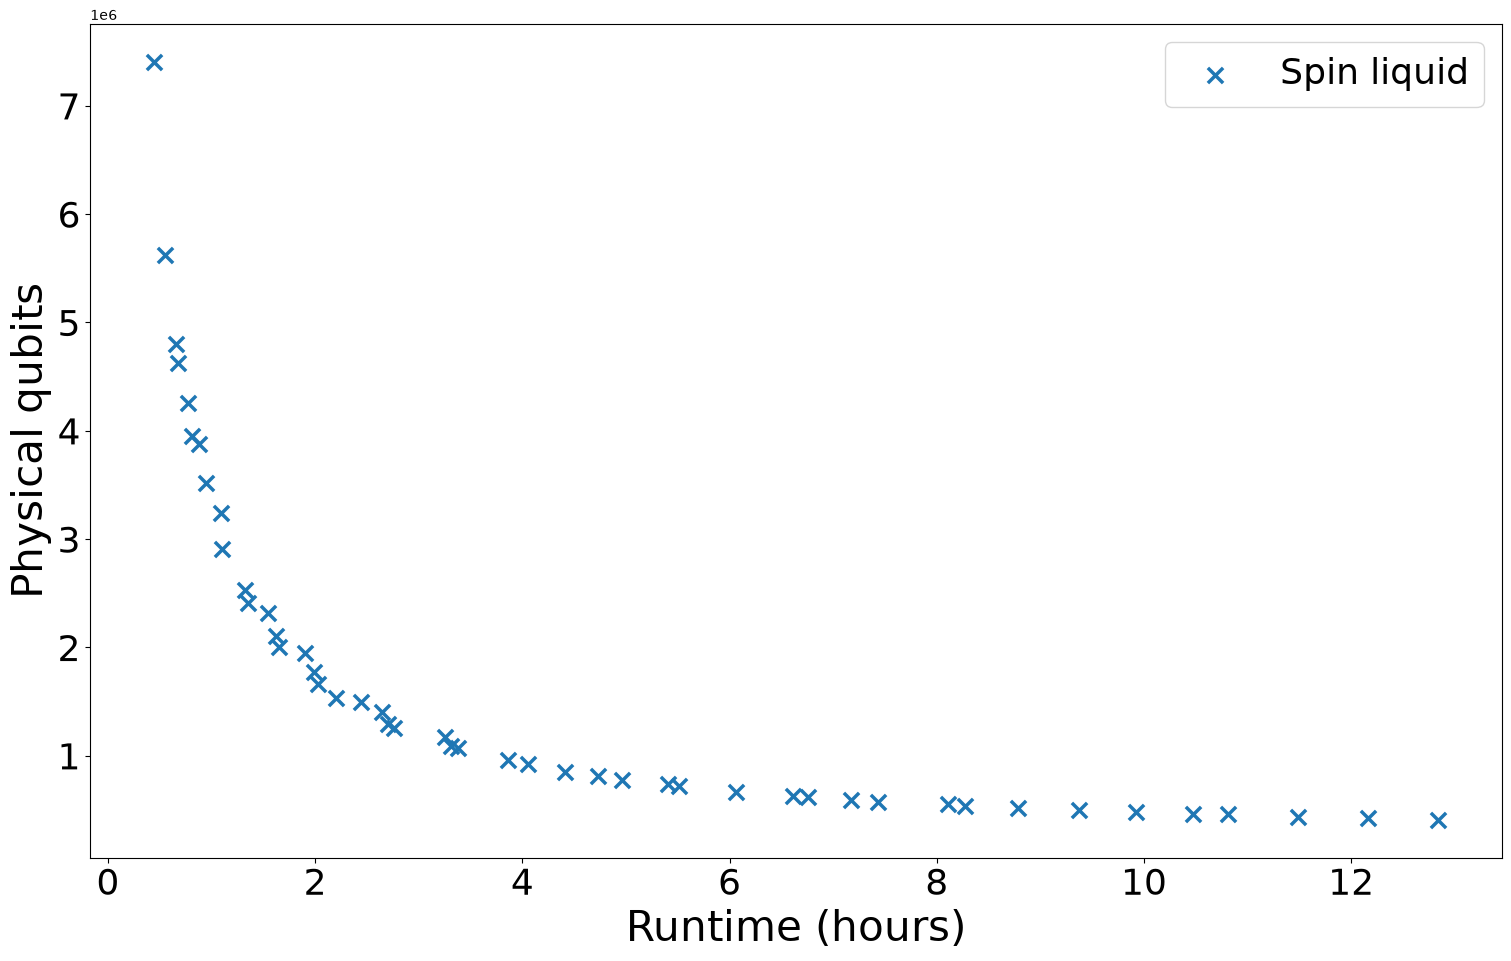

In [7]:
fig = plot_estimates([results], runtime_unit="hours", figsize=(15, 9.5),
                     scatter_args={"marker": "x", "s": 120, "linewidths": 2.5})
ax = fig.axes[0]
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.set_ylabel(ax.get_ylabel(), fontsize=30)
ax.tick_params(axis="both", labelsize=26)
ax.legend(fontsize=26, loc="upper right")
fig.set_layout_engine("constrained")
fig